# Saving a trained model — joblib and pickle

## The story

Ravi trained a classifier on Friday. It scored well, he was pleased, and he shut
the laptop.

On Monday the kernel was dead and the model was gone. `classifier` had only ever
been a variable in memory. The notebook still held the *code* that built it, but
not the thing itself.

**So he retrained at the top of every run.** For a hundred rows that costs
milliseconds and nobody notices. Then the real model arrived: a forest on half a
million rows, four minutes to fit. His API now spent four minutes retraining on
every restart, and every deploy was four minutes of failing requests.

**The worse problem was quieter.** Each retrain produced a *slightly different*
model — new rows had arrived, and the fit is not identical. When a customer asked
why they had been rejected last Tuesday, Ravi could not answer, because the model
that made that decision no longer existed anywhere.

What he needed was to **freeze the fitted object into a file**. Train once, save
the result, and load that exact file whenever a prediction is needed. The file
*is* the model.

> 📘 **Instructor Curriculum** — Session 21.

## What is actually being saved

This is the part that makes the rest obvious.

`fit()` does not change your code. It fills in **attributes on the object**, and
scikit-learn marks every learned attribute with a trailing underscore:
`theta_`, `coef_`, `classes_`. Those numbers *are* the model. Everything else —
how to multiply them, how to compare them — already lives in the scikit-learn
library on the machine.

So saving a model means **serialising an object's learned numbers to bytes**, and
loading means rebuilding the object from those bytes.

If you have written Java, this is exactly `Serializable` plus
`ObjectOutputStream`: the field values travel, the class does not. And it comes
with the same warning attached, which we get to at the end.

## Setup

`pickle` is in the standard library. `joblib` arrives with scikit-learn, so
there is nothing new to install.

Every file written below goes to a **temporary folder**, so this notebook leaves
nothing behind in the repository. In your own work the path would be a real one
like `models/churn_v3.joblib`.

In [1]:
import os, pickle, time, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

TMP = tempfile.mkdtemp(prefix="saved_models_")   # nothing is written into the repo

C1, C2 = "#e4572e", "#1f7a8c"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})

print("scikit-learn", sklearn.__version__, "| joblib", joblib.__version__)
print("writing models to", TMP)

scikit-learn 1.8.0 | joblib 1.5.3
writing models to /var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/saved_models_aiwsdpvg


## The model from the session

Same car data as the class notebook: `Age` and `Income` in, "did they buy the
car" out.

One honest note before the scores appear — 93 of the 100 rows are class 0. A
model that always answered "no" would already look about 93% right, so accuracy
here is not the interesting part. **What matters in this lesson is only that the
saved model behaves identically to the original.**

In [2]:
cars = pd.read_csv("../Data/Car.csv")
X, y = cars[["Age", "Income"]], cars["Car"]

print("rows:", len(cars), "| class balance:", y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

model = GaussianNB().fit(X_train, y_train)
print("accuracy on held-out rows:", round(model.score(X_test, y_test), 4))

rows: 100 | class balance: {0: 93, 1: 7}
accuracy on held-out rows: 0.95


## The whole model, printed

Here is the claim from earlier, made concrete. A fitted `GaussianNB` on two
columns is **one mean and one variance per column per class**, plus how common
each class was. Ten numbers. That is the entire thing.

In [3]:
print("classes_     :", model.classes_)
print("class_prior_ :", model.class_prior_.round(3))
print("\ntheta_ (mean of each column, per class)")
print(pd.DataFrame(model.theta_, index=model.classes_, columns=X.columns).round(1))
print("\nvar_ (variance of each column, per class)")
print(pd.DataFrame(model.var_, index=model.classes_, columns=X.columns).round(1))

n_numbers = model.theta_.size + model.var_.size + model.class_prior_.size
print("\nlearned numbers in total:", n_numbers)

classes_     : [0 1]
class_prior_ : [0.912 0.088]

theta_ (mean of each column, per class)
    Age    Income
0  30.0   58123.3
1  30.7  121714.3

var_ (variance of each column, per class)
    Age       Income
0  51.4  524793020.2
1   4.8  426204082.5

learned numbers in total: 10


## Save it, load it, check it

Two lines to write, one to read. `joblib.dump` takes the object and a path.

In [4]:
path = os.path.join(TMP, "car_model.joblib")

joblib.dump(model, path)                 # write
loaded = joblib.load(path)               # read back into a new object

before = model.predict(X_test)
after  = loaded.predict(X_test)

print("file:", os.path.basename(path), "|", os.path.getsize(path), "bytes")
print("same object in memory? ", loaded is model)
print("identical predictions? ", np.array_equal(before, after))
print("identical learned numbers?", np.array_equal(model.theta_, loaded.theta_))

file: car_model.joblib | 1111 bytes
same object in memory?  False
identical predictions?  True
identical learned numbers? True


`loaded is model` is `False` — it is a genuinely new object, rebuilt from bytes.
Every prediction it makes is identical, because every learned number came back
unchanged.

The picture below is the same statement drawn out: the boundary the original
model draws, and the boundary the reloaded model draws.

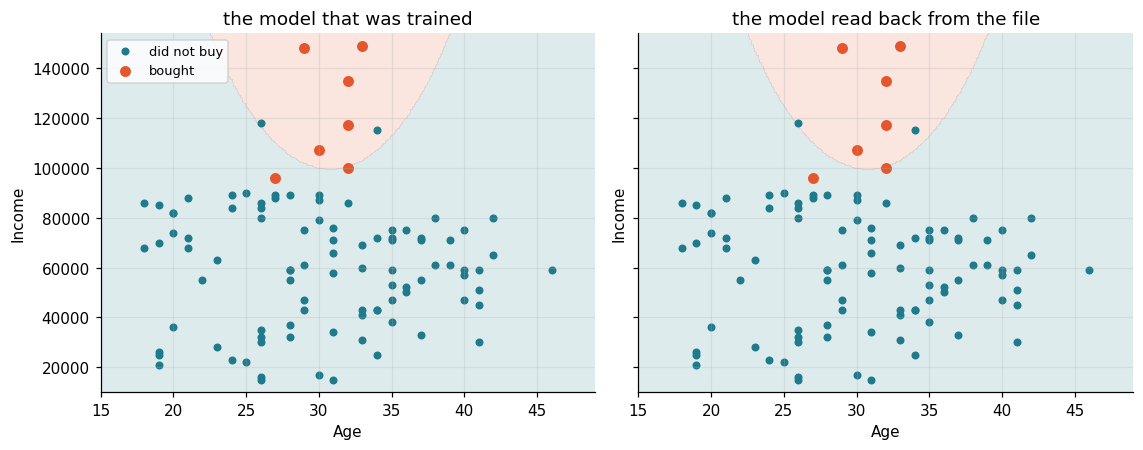

In [5]:
def boundary(ax, clf, title):
    xx, yy = np.meshgrid(np.linspace(X["Age"].min() - 3, X["Age"].max() + 3, 300),
                         np.linspace(X["Income"].min() - 5000, X["Income"].max() + 5000, 300))
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["Age", "Income"])
    zz = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=.15, colors=[C2, C1], levels=[-.5, .5, 1.5])
    ax.scatter(*X[y == 0].T.values, s=18, c=C2, label="did not buy")
    ax.scatter(*X[y == 1].T.values, s=38, c=C1, label="bought")
    ax.set(title=title, xlabel="Age", ylabel="Income")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
boundary(axes[0], model,  "the model that was trained")
boundary(axes[1], loaded, "the model read back from the file")
axes[0].legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

Two drawings of the same line, because it *is* the same line. That is the whole
promise of saving a model.

## joblib or pickle?

Both exist, the class notebook used both, and the difference is smaller than it
looks: **joblib writes a pickle.** Same protocol underneath — it only handles
large NumPy arrays its own way, and adds a couple of options pickle has no word
for.

The usual advice is "joblib is faster for scikit-learn". Rather than repeat it,
measure it on this machine.

In [6]:
X_big, y_big = make_classification(n_samples=20_000, n_features=20, random_state=0)
big = RandomForestClassifier(n_estimators=120, random_state=0).fit(X_big, y_big)

# three ways to write the same object, each a (save, load) pair
ways = {
  "pickle":            (lambda o, p: pickle.dump(o, open(p, "wb")),
                        lambda p: pickle.load(open(p, "rb"))),
  "joblib":            (lambda o, p: joblib.dump(o, p),
                        joblib.load),
  "joblib compress=3": (lambda o, p: joblib.dump(o, p, compress=3),
                        joblib.load),
}

def measure(obj, tag, way):
    save, load = ways[way]
    p = os.path.join(TMP, f"{tag}.{way.split()[0]}{'z' if 'compress' in way else ''}")
    t0 = time.perf_counter(); save(obj, p)
    t1 = time.perf_counter(); back = load(p)
    t2 = time.perf_counter()
    assert back is not obj                       # rebuilt, not handed back
    return {"mb": os.path.getsize(p) / 1024**2,
            "save_ms": (t1 - t0) * 1000, "load_ms": (t2 - t1) * 1000}

results = {(tag, way): measure(obj, tag, way)
           for tag, obj in [("small", model), ("big", big)]
           for way in ways}

print(f"{'model':8s}{'way':20s}{'size (MB)':>11s}{'save (ms)':>11s}{'load (ms)':>11s}")
for (tag, way), r in results.items():
    print(f"{tag:8s}{way:20s}{r['mb']:11.3f}{r['save_ms']:11.1f}{r['load_ms']:11.1f}")

model   way                   size (MB)  save (ms)  load (ms)
small   pickle                    0.001        0.3        0.3
small   joblib                    0.001        0.4        0.2
small   joblib compress=3         0.001        0.3        0.2
big     pickle                   25.373        5.8        6.0
big     joblib                   25.384       13.5       13.8
big     joblib compress=3         5.409      139.8       29.2


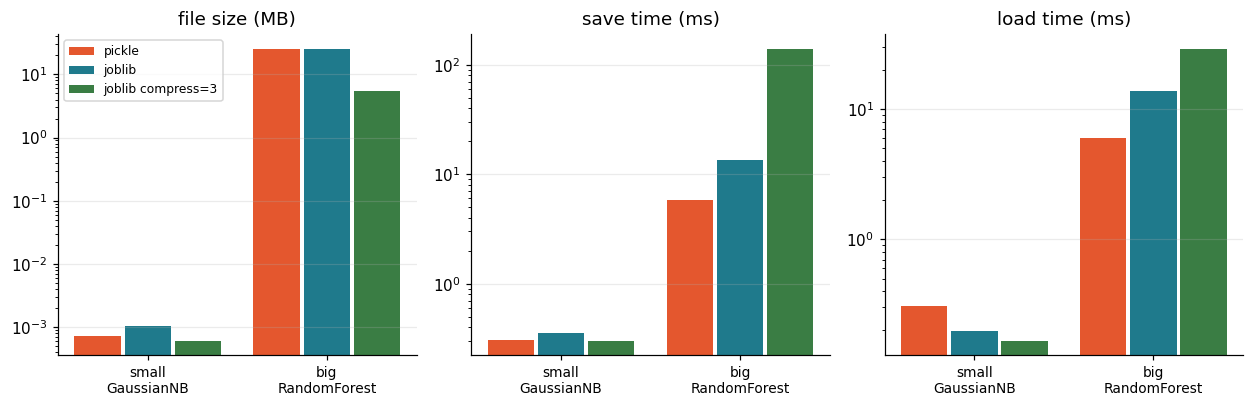

In [7]:
tags = ["small", "big"]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
cols = {"pickle": C1, "joblib": C2, "joblib compress=3": "#3a7d44"}
for ax, field, label in zip(axes, ["mb", "save_ms", "load_ms"],
                            ["file size (MB)", "save time (ms)", "load time (ms)"]):
    xs = np.arange(len(tags))
    for k, (way, col) in enumerate(cols.items()):
        ax.bar(xs + (k - 1) * .28, [results[(t, way)][field] for t in tags],
               .26, color=col, label=way)
    ax.set(title=label, xticks=xs, yscale="log")
    ax.set_xticklabels(["small\nGaussianNB", "big\nRandomForest"], fontsize=9)
    ax.grid(axis="x", visible=False)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Read the bars on a log scale — the two models are orders of magnitude apart.

**The received wisdom did not survive the measurement.** Plain `joblib` and plain
`pickle` produce a file of the same size, and joblib is not the faster of the
two here. That is not a bug in either one: modern pickle (protocol 5) grew the
efficient array handling that joblib was invented to provide.

What joblib still gives you, and pickle has no word for:

| Option | What it does | The cost |
|---|---|---|
| `compress=3` | roughly **5× smaller** on disk | saving gets much slower, loading somewhat slower |
| `mmap_mode="r"` | maps big arrays straight off disk instead of copying them into memory | read-only, and only helps arrays |

`mmap_mode` is the one that matters in a service. Four API workers loading the
same 200 MB model normally hold four copies; memory-mapped, they share one.

**So: use `joblib` for scikit-learn models** — it is what the documentation
says, and those two options are there when you need them. Just do not expect it
to be faster, because on this machine it is not. Keep `pickle` for ordinary
Python objects with no arrays in them: a settings dict, a label mapping.

## Trap 1 — saving the model but not the preparation

This is the one that actually breaks in production, and it is silent.

A model almost never sees raw columns. Something scales them first. If you save
only the estimator, the scaler stays behind in the dead kernel — and at serving
time raw values get fed to a model that was trained on scaled ones.

Nothing raises. The predictions are simply wrong. Here it is, measured.

In [8]:
# a model that genuinely depends on scaling: Income is ~1000x larger than Age,
# so an unscaled distance is really "distance in Income"
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(Xa)
knn    = KNeighborsClassifier(n_neighbors=5).fit(scaler.transform(Xa), ya)

# the wrong way: only the estimator was saved, so raw columns reach it
joblib.dump(knn, os.path.join(TMP, "knn_only.joblib"))
knn_only = joblib.load(os.path.join(TMP, "knn_only.joblib"))
wrong = knn_only.predict(Xb.values)   # .values: it was fitted on a bare array

# the right way: the whole pipeline is one object, so the scaler travels with it
pipe = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]).fit(Xa, ya)
joblib.dump(pipe, os.path.join(TMP, "pipeline.joblib"))
right = joblib.load(os.path.join(TMP, "pipeline.joblib")).predict(Xb)

print("model only, fed raw columns :", (wrong == yb).mean().round(4), "accuracy")
print("whole pipeline saved        :", (right == yb).mean().round(4), "accuracy")
print("\npredictions that differ between the two:", int((wrong != right).sum()), "of", len(yb))

model only, fed raw columns : 0.0 accuracy
whole pipeline saved        : 0.95 accuracy

predictions that differ between the two: 19 of 20


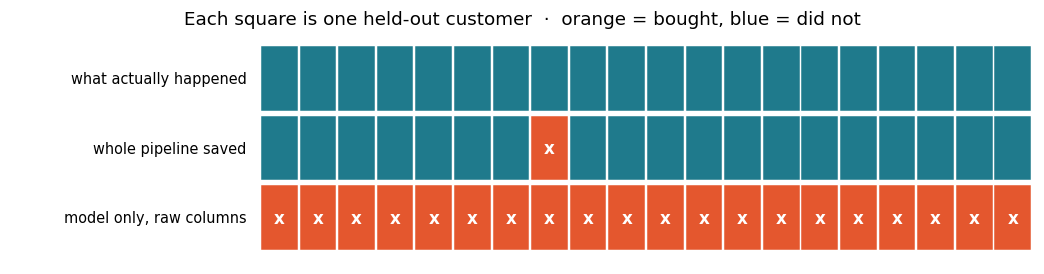

In [9]:
rows = [("what actually happened", np.asarray(yb)),
        ("whole pipeline saved",   right),
        ("model only, raw columns", wrong)]

fig, ax = plt.subplots(figsize=(9.6, 2.6))
for r, (label, vals) in enumerate(rows):
    for i, v in enumerate(vals):
        ax.add_patch(plt.Rectangle((i, -r), .9, .9, color=C1 if v else C2))
    ax.text(-.4, -r + .45, label, ha="right", va="center", fontsize=9.5)
    if r:                                   # mark every square that is wrong
        for i, (v, t) in enumerate(zip(vals, np.asarray(yb))):
            if v != t:
                ax.text(i + .45, -r + .45, "x", ha="center", va="center",
                        color="w", fontsize=11, fontweight="bold")
ax.set(xlim=(-6.5, len(right)), ylim=(-2.2, 1.1), xticks=[], yticks=[],
       title="Each square is one held-out customer  ·  orange = bought, blue = did not")
ax.grid(False)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.show()

No exception, no warning — two different answers from what looks like the same
model. The fix is a rule, not a check:

**Save the `Pipeline`, not the estimator.** Whatever had to happen to the data
before `fit` must be inside the object you serialise, so it happens again before
`predict`.

## Trap 2 — the file does not contain scikit-learn

A pickle stores your object's *numbers* and a **reference to its class** — the
import path, written as plain text in the file. It does not store the class's
code.

In [10]:
raw = pickle.dumps(model)
print("bytes on disk:", len(raw))
print("class paths written into the file:")
for token in [b"sklearn.naive_bayes", b"GaussianNB", b"numpy"]:
    print(f"   {token.decode():22s} present: {token in raw}")

print("\nsaved with scikit-learn", sklearn.__version__,
      "\nload it where that version differs and the rebuild may fail, or quietly differ")

bytes on disk: 757
class paths written into the file:
   sklearn.naive_bayes    present: True
   GaussianNB             present: True
   numpy                  present: True

saved with scikit-learn 1.8.0 
load it where that version differs and the rebuild may fail, or quietly differ


`sklearn.naive_bayes` is sitting in the file as text. On load, Python imports
that module *from the machine doing the loading* and rebuilds the object with
whatever the class looks like there.

So a saved model is only meaningful next to the versions it was born with.
Write them down beside the file:

- pin `scikit-learn`, `numpy` and `joblib` in the environment that serves it;
- save the version string with the model — a small dict works:
  `joblib.dump({"model": pipe, "sklearn": sklearn.__version__}, path)`;
- treat a model file as a build artefact, not as source. It belongs in artefact
  storage, not in git.

## Trap 3 — never load a pickle you did not create

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor
> curriculum.*

Loading a pickle **runs code**. The format is allowed to say "to rebuild me, call
this function with these arguments", and `load` obeys without asking.

Here is a harmless object that proves it. Nothing malicious happens — it prints a
line — but the same mechanism would run any command.

In [11]:
class Harmless:
    '''A deliberately benign demonstration: it prints when it is unpickled.'''
    def __reduce__(self):
        # "to rebuild me, call print(...)" — load() will do exactly that
        return (print, ("[!] this line was executed by pickle.load, not by me",))

payload = pickle.dumps(Harmless())          # pretend this arrived from outside

print("about to load a file we did not create...")
pickle.loads(payload)                        # loads() is load() without the file
print("...and the load did that on its own.")

about to load a file we did not create...
[!] this line was executed by pickle.load, not by me
...and the load did that on its own.


An uploaded `.pkl` is executable input. Treat it exactly like an uploaded `.sh`.

For a service this means: **never** unpickle a file a user supplied, load models
only from storage you control, and check the artefact's checksum before loading
it. If you truly must accept a model from outside, use a format that carries data
only — ONNX, or the safetensors format — rather than pickle.

## Putting it in a service

The class notebook ended on `pip install flask fastapi`, which is exactly where
this goes next. The whole point of the file is the line that loads it:

```python
from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
model = joblib.load("models/car_v1.joblib")   # once, at startup — not per request

@app.post("/predict")
def predict(age: int, income: int):
    row = pd.DataFrame([{"Age": age, "Income": income}])
    return {"buys": int(model.predict(row)[0])}
```

Two details carry all the weight:

1. **`joblib.load` sits at module level.** Loading inside the handler would pay
   the disk read and the rebuild on every request. Ravi's four-minute retrain was
   the extreme version of the same mistake.
2. **The loaded object is a `Pipeline`,** so the raw `Age` and `Income` coming off
   the request get scaled exactly as they were in training, by the same fitted
   scaler.

For a backend engineer the shape is familiar: the model file is a read-only
dependency loaded at boot, versioned and rolled out like any other artefact — not
something rebuilt per request.

## Common mistakes

1. **Saving the estimator instead of the pipeline.** The scaler or encoder is
   left behind and predictions go quietly wrong.
2. **Loading the model inside the request handler.** Correct answers, needless
   latency on every call.
3. **Committing model files to git.** They are large binaries that change on
   every retrain; they belong in artefact storage with a version tag.
4. **Assuming a `.pkl` is portable.** It carries import paths, not code. A
   different scikit-learn version can refuse it or rebuild it differently.
5. **Unpickling a file from outside your system.** That is remote code
   execution, not deserialisation.

## Key takeaway

**If you remember only one thing:** `fit()` produces an object full of learned
numbers, and `joblib.dump` freezes that object into a file so the *exact* model —
not a retrained cousin — answers tomorrow's request.

Save the whole pipeline, load it once at startup, pin the versions beside it, and
never load a pickle you did not create.